# Tutorial: Visualization from CSV Output Files

This notebook demonstrates how to use `epymodelingsuite.visualization.core` to generate quantile plots from CSV output files.

Steps
1. Loading hub-formatted CSV output files
2. Loading surveillance data from flu_hosp_25.csv
3. Generating single quantile plots for individual locations
4. Generating grid plots with multiple locations
5. Adding surveillance data overlays
6. Customizing plot appearance

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from epymodelingsuite.visualization.core import (
    plot_quantiles,
    plot_quantiles_grid,
    plot_surveillance_scatter,
    figure_to_output_object,
)
from epymodelingsuite.utils.location import convert_location_name_format

%matplotlib inline

## 1. Load Hub-Formatted CSV Data

Hub-formatted CSV files have the following structure:
- `location`: Location identifier
- `reference_date`: Date when forecast was made
- `horizon`: Number of weeks ahead (-1 for retrospective, 0+ for prospective)
- `target_end_date`: Date for this forecast value
- `target`: What is being forecasted (e.g., "wk inc flu hosp")
- `output_type`: Type of output ("quantile" for quantiles)
- `output_type_id`: Quantile level (e.g., 0.025, 0.5, 0.975)
- `value`: Forecasted value

In [8]:
# Load the CSV file
csv_path = "/home/minami/Developer/epymodelingsuite__visualization/pipeline_flu_202546_smc_202541-202546_20251118-190056-1ec87327_outputs_output_hub_formatted.csv"
df = pd.read_csv(csv_path)

# Inspect the data
print("CSV shape:", df.shape)
print("\nFirst few rows:")
df.head()

CSV shape: (6750, 8)

First few rows:


,location,reference_date,horizon,target_end_date,target,output_type,output_type_id,value
0,US,2025-11-15,-1,2025-11-08,wk inc flu hosp,quantile,0.01,1110.0
1,US,2025-11-15,0,2025-11-15,wk inc flu hosp,quantile,0.01,1169.0
2,US,2025-11-15,1,2025-11-22,wk inc flu hosp,quantile,0.01,1229.0
3,US,2025-11-15,2,2025-11-29,wk inc flu hosp,quantile,0.01,1278.0
4,US,2025-11-15,3,2025-12-06,wk inc flu hosp,quantile,0.01,1378.0


In [9]:
# Check available locations
print("Locations in data:")
locations = df['location'].unique()
print(locations)

# Check reference date
print("\nReference dates:")
print(df['reference_date'].unique())

# Check quantile levels
print("\nQuantile levels:")
print(sorted(df[df['output_type'] == 'quantile']['output_type_id'].unique()))

Locations in data:
['US' '01' '05' '04' '06' '08' '09' '11' '10' '12' '13' '15' '19' '16'
 '17' '18' '20' '21' '22' '25' '24' '23' '26' '27' '29' '28' '30' '37'
 '38' '31' '33' '34' '35' '32' '36' '39' '40' '41' '42' '44' '45' '46'
 '47' '48' '49' '51' '53' '55' '54' '56']

Reference dates:
['2025-11-15']

Quantile levels:
['0.01', '0.02', '0.05', '0.1', '0.15', '0.2', '0.25', '0.3', '0.35', '0.4', '0.45', '0.5', '0.55', '0.6', '0.65', '0.7', '0.75', '0.8', '0.85', '0.9', '0.95', '0.98', '0.99']


## 2. Prepare Data for Visualization

The visualization functions expect data in a specific format:
- Columns: `date`, `quantile`, `value`
- `date`: datetime column with forecast dates
- `quantile`: quantile level (0.025, 0.5, 0.975, etc.)
- `value`: forecasted value at that quantile

We'll transform the hub format into this expected format.

In [10]:
def prepare_quantile_data_for_plotting(df_hub, location=None, reference_date=None):
    """
    Convert hub-formatted CSV to format expected by visualization.core.
    
    Parameters
    ----------
    df_hub : pd.DataFrame
        Hub-formatted data with columns: location, reference_date, target_end_date,
        output_type, output_type_id, value
    location : str, optional
        Filter to specific location. If None, uses all data.
    reference_date : str, optional
        Filter to specific reference date. If None, uses all data.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns [date, quantile, value] ready for plotting
    """
    df = df_hub.copy()
    
    # Filter by location if specified
    if location is not None:
        df = df[df['location'] == location]
    
    # Filter by reference date if specified
    if reference_date is not None:
        df = df[df['reference_date'] == reference_date]
    
    # Filter to quantile outputs only
    df = df[df['output_type'] == 'quantile'].copy()
    
    # Rename columns to match expected format
    df = df.rename(columns={
        'target_end_date': 'date',
        'output_type_id': 'quantile'
    })
    
    # Keep only needed columns
    df = df[['date', 'quantile', 'value']]
    
    # Ensure date is datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # Ensure quantile is float
    df['quantile'] = df['quantile'].astype(float)
    
    return df

# Test the function
df_plot = prepare_quantile_data_for_plotting(df, location='US')
print("Prepared data shape:", df_plot.shape)
df_plot.head(15)

Prepared data shape: (115, 3)


,date,quantile,value
0,2025-11-08,0.01,1110.0
1,2025-11-15,0.01,1169.0
2,2025-11-22,0.01,1229.0
3,2025-11-29,0.01,1278.0
4,2025-12-06,0.01,1378.0
5,2025-11-08,0.02,1141.0
6,2025-11-15,0.02,1193.0
7,2025-11-22,0.02,1255.0
8,2025-11-29,0.02,1328.0
9,2025-12-06,0.02,1421.0


In [11]:
# Prepare data for US
df_us = prepare_quantile_data_for_plotting(df, location='US')

## 3. Load and Prepare Surveillance Data

Load the actual flu hospitalization surveillance data from flu_hosp_25.csv.

In [13]:
# Load surveillance data
surveillance_csv_path = "/home/minami/Developer/epymodelingsuite__visualization/flu_hosp_25.csv"
df_surv_raw = pd.read_csv(surveillance_csv_path)

print("Surveillance data shape:", df_surv_raw.shape)
print("\nColumns:", df_surv_raw.columns.tolist())
print("\nFirst few rows:")
df_surv_raw.head()

Surveillance data shape: (5044, 5)

Columns: ['location_iso', 'location_code', 'target_end_date', 'epiweek', 'hospitalizations']

First few rows:


,location_iso,location_code,target_end_date,epiweek,hospitalizations
0,US-AL,01,2024-01-06,202401,348.0
1,US-AL,01,2024-01-13,202402,226.0
2,US-AL,01,2024-01-20,202403,169.0
3,US-AL,01,2024-01-27,202404,142.0
4,US-AL,01,2024-02-03,202405,103.0


In [14]:
def prepare_surveillance_data(df_surv_raw):
    """
    Prepare surveillance data for plotting.
    
    Parameters
    ----------
    df_surv_raw : pd.DataFrame
        Raw surveillance data with columns: location_iso, location_code, 
        target_end_date, epiweek, hospitalizations
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns [location, date, value]
    """
    df = df_surv_raw.copy()
    
    # Rename columns to standard format
    df = df.rename(columns={
        'location_iso': 'location',
        'target_end_date': 'date',
        'hospitalizations': 'value'
    })
    
    # Keep only needed columns
    df = df[['location', 'date', 'value']]
    
    # Ensure date is datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # Drop NaN values
    df = df.dropna(subset=['value'])
    
    return df

def convert_location_fips_to_iso(location_code):
    """
    Convert FIPS location code to ISO format for better readability.
    
    Parameters
    ----------
    location_code : str
        FIPS location code (e.g., "US", "01", "06")
    
    Returns
    -------
    str
        ISO format location code (e.g., "US", "US-AL", "US-CA")
    """
    try:
        return convert_location_name_format(location_code, "ISO")
    except (AssertionError, KeyError, IndexError):
        # If conversion fails, return original code
        return location_code

# Prepare surveillance data
df_surveillance = prepare_surveillance_data(df_surv_raw)

print("Prepared surveillance data shape:", df_surveillance.shape)
print("\nLocations in surveillance data:", sorted(df_surveillance['location'].unique())[:10], "...")

Prepared surveillance data shape: (5044, 3)

Locations in surveillance data: ['US', 'US-AK', 'US-AL', 'US-AR', 'US-AZ', 'US-CA', 'US-CO', 'US-CT', 'US-DC', 'US-DE'] ...


In [15]:
# Filter surveillance data for US and check date range
df_surv_us = df_surveillance[df_surveillance['location'] == 'US']

print(f"US surveillance data: {len(df_surv_us)} rows")
print(f"Date range: {df_surv_us['date'].min()} to {df_surv_us['date'].max()}")
print(f"Value range: {df_surv_us['value'].min():.0f} to {df_surv_us['value'].max():.0f}")
print("\nLast 10 rows:")
df_surv_us.tail(10)

US surveillance data: 97 rows
Date range: 2024-01-06 00:00:00 to 2025-11-08 00:00:00
Value range: 223 to 55421

Last 10 rows:


,location,date,value
5034,US,2025-09-06,943.0
5035,US,2025-09-13,991.0
5036,US,2025-09-20,867.0
5037,US,2025-09-27,986.0
5038,US,2025-10-04,949.0
5039,US,2025-10-11,970.0
5040,US,2025-10-18,1071.0
5041,US,2025-10-25,1124.0
5042,US,2025-11-01,1271.0
5043,US,2025-11-08,1618.0


## 4. Create Plot with Surveillance Data Overlay

Overlay surveillance data on top of the forecast quantiles.

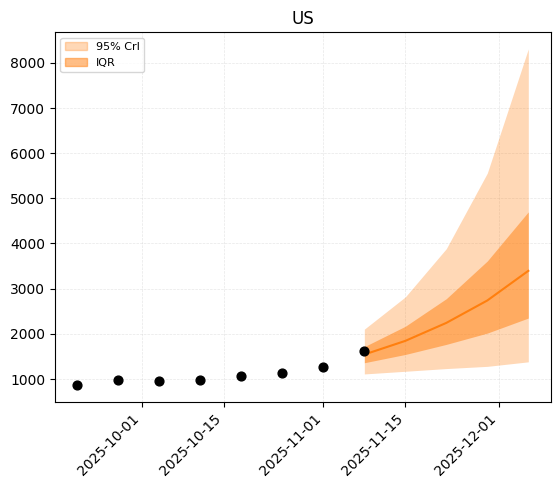

In [16]:
# Create plot with surveillance overlay
fig, ax = plot_quantiles(
    df_quantiles=df_us,
    value_col='value',
    date_col='date',
    quantile_col='quantile',
    color='C1',
    title='US'
)

# Limit surveillance data to latest 8 points
df_surv_us_limited = df_surv_us[['date', 'value']].sort_values('date').tail(8)

# Add surveillance data overlay
plot_surveillance_scatter(
    df_surveillance=df_surv_us_limited,
    date_col='date',
    value_col='value',
    color='black',
    size=40.0,
    ax=ax
)

plt.show()

## 5. Multi-Location Grid Plot

Use `plot_quantiles_grid()` to create a grid of plots for multiple locations.

In [17]:
# Get all locations in the data
print(f"Number of locations: {len(locations)}")
print(f"\nLocations: {sorted(locations)}")

Number of locations: 50

Locations: ['01', '04', '05', '06', '08', '09', '10', '11', '12', '13', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '44', '45', '46', '47', '48', '49', '51', '53', '54', '55', '56', 'US']


In [18]:
# Prepare data for multiple locations
locations_to_plot = sorted(locations)

location_quantiles = {}

for loc in locations_to_plot:
    quant_df = prepare_quantile_data_for_plotting(df, location=loc)
    
    if quant_df is not None and not quant_df.empty:
        # Convert FIPS location code to ISO format for better readability
        iso_loc = convert_location_fips_to_iso(loc)
        location_quantiles[iso_loc] = quant_df

print(f"Prepared quantile data for {len(location_quantiles)} locations")
print(f"Location names: {list(location_quantiles.keys())}")

Prepared quantile data for 50 locations
Location names: ['US-AL', 'US-AZ', 'US-AR', 'US-CA', 'US-CO', 'US-CT', 'US-DE', 'US-DC', 'US-FL', 'US-GA', 'US-HI', 'US-ID', 'US-IL', 'US-IN', 'US-IA', 'US-KS', 'US-KY', 'US-LA', 'US-ME', 'US-MD', 'US-MA', 'US-MI', 'US-MN', 'US-MS', 'US-MO', 'US-MT', 'US-NE', 'US-NV', 'US-NH', 'US-NJ', 'US-NM', 'US-NY', 'US-NC', 'US-ND', 'US-OH', 'US-OK', 'US-OR', 'US-PA', 'US-RI', 'US-SC', 'US-SD', 'US-TN', 'US-TX', 'US-UT', 'US-VA', 'US-WA', 'US-WV', 'US-WI', 'US-WY', 'US']


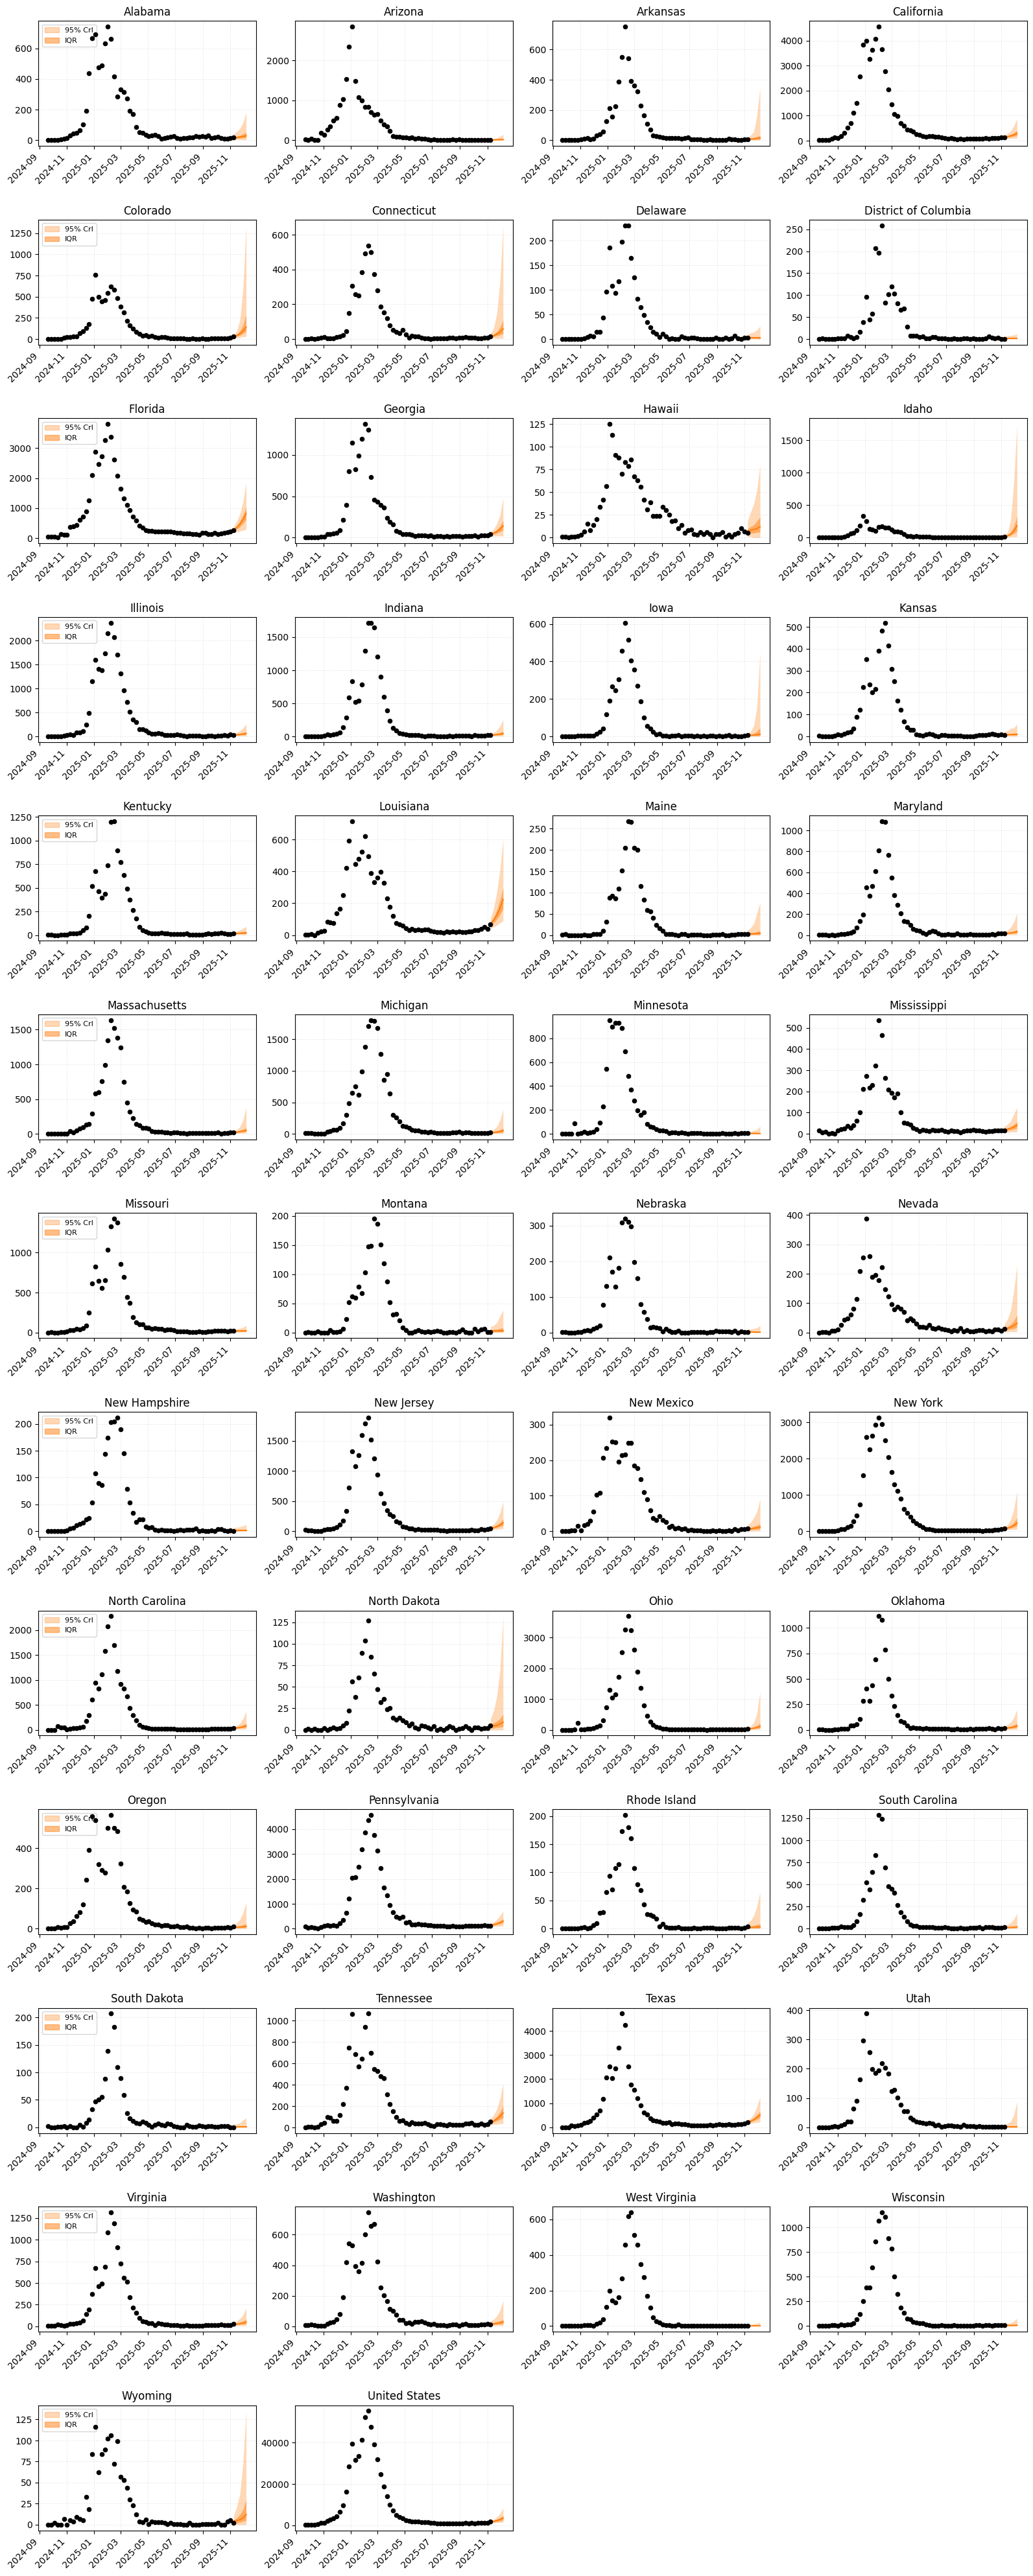

In [24]:
# Create grid plot
fig, axes = plot_quantiles_grid(
    location_quantiles=location_quantiles,
    value_col='value',
    date_col='date',
    quantile_col='quantile',
    color='C1',
    panels_per_row=4,
    figsize=(16, 40)
)

# Add surveillance data overlay to each panel
for idx, (loc, quant_df) in enumerate(location_quantiles.items()):
    r = idx // 4
    c = idx % 4
    ax = axes[r, c]
    
    # Get surveillance data for this location
    surv_df = df_surveillance[df_surveillance['location'] == loc][['date', 'value']].copy()
    
    if not surv_df.empty:
        # Sort by date and limit to latest 8 points
        surv_df = surv_df.sort_values('date').tail(60)
        
        plot_surveillance_scatter(
            df_surveillance=surv_df,
            date_col='date',
            value_col='value',
            color='black',
            size=20.0,  # Smaller points for grid
            ax=ax
        )

plt.show()

## 6. Save Plots to Files


In [25]:
fig.savefig('flu_202546_smc_202541-202546_20251118-190056-1ec87327_full.pdf', bbox_inches='tight')
plt.close(fig)

## 7. Complete Example: Processing Multiple CSV Files

In [96]:
def generate_grid_plot_from_hub_csv(
    csv_path,
    surveillance_csv_path=None,
    surveillance_points=8,
    locations_to_plot=None,
    color='steelblue',
):
    """
    Generate all standard quantile plots from a hub-formatted CSV file.
    
    Parameters
    ----------
    csv_path : str or Path
        Path to hub-formatted CSV file
    surveillance_csv_path : str or Path, optional
        Path to surveillance data CSV file
    surveillance_points : int
        Number of latest surveillance points to overlay on each plot
    locations_to_plot : list of str, optional
        List of locations to plot (in FIPS format). If None, plots all locations.
    color : str
        Color for quantile ribbons
    """
    
    # Load forecast data
    df = pd.read_csv(csv_path)
    
    # Load surveillance data if provided
    surveillance_df = None
    if surveillance_csv_path is not None:
        df_surv_raw = pd.read_csv(surveillance_csv_path)
        surveillance_df = prepare_surveillance_data(df_surv_raw)
    
    # Get locations
    if locations_to_plot is None:
        locations_to_plot = sorted(df['location'].unique())
    
    #  Generate grid plot
    print("\nGenerating grid plot...")
    location_quantiles = {}
    
    for loc in locations_to_plot:
        quant_df = prepare_quantile_data_for_plotting(df, location=loc)
        
        if quant_df is not None and not quant_df.empty:
            # Convert FIPS to ISO for better readability
            iso_loc = convert_location_fips_to_iso(loc)
            location_quantiles[iso_loc] = quant_df
    
    fig, axes = plot_quantiles_grid(
        location_quantiles=location_quantiles,
        value_col='value',
        date_col='date',
        quantile_col='quantile',
        color=color,
        panels_per_row=4
    )
    
    # Add surveillance overlay to each panel
    if surveillance_df is not None:
        for idx, (loc, quant_df) in enumerate(location_quantiles.items()):
            r = idx // 4
            c = idx % 4
            ax = axes[r, c]
            
            surv_df = surveillance_df[surveillance_df['location'] == loc][['date', 'value']].copy()
            if not surv_df.empty:
                # Limit to latest 8 points
                surv_df = surv_df.sort_values('date').tail(surveillance_points)
                
                plot_surveillance_scatter(
                    df_surveillance=surv_df,
                    date_col='date',
                    value_col='value',
                    color='black',
                    size=20.0,
                    ax=ax
                )
    
    plt.close(fig)
    return fig, axes

In [97]:
fig, axes = generate_grid_plot_from_hub_csv(
    csv_path='pipeline_flu_202546_top_fraction_202541-202546_20251118-184809-4535b279_outputs_output_hub_formatted (3).csv',
    surveillance_csv_path='flu_hosp_25.csv',
    locations_to_plot=None,
    color='C1'
)


Generating grid plot...


In [ ]:
fig.savefig('us_forecast.pdf', bbox_inches='tight')
plt.close(fig)